# Step 1: Data Cleaning & Feature Engineering
**Placement Prediction & College Analytics Project**

This notebook covers the data cleaning process for the college placement dataset. Since the raw dataset contains only baseline academic and skill-related variables, we will:
1. Setup the project folder structures.
2. Enrich the raw data by simulating realistic target and feature columns (such as placement status, salary packages, communication skills, project count, and hiring companies) using logical distribution formulas.
3. Perform data cleaning (remove duplicates, handle missing values, and handle outliers).
4. Standardize branch and department names.
5. Convert categorical Yes/No strings into numerical binary form.
6. Create new derived features to assist modeling and analytics.
7. Export the cleaned dataset.

## 1. Import Libraries & Set Up Directories

In [1]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure project directories exist
dirs = ['../data/raw', '../data/cleaned', '../sql', '../notebooks', '../models']
for d in dirs:
    os.makedirs(d, exist_ok=True)

# Copy raw file to raw folder if found in parent or workspace root
if os.path.exists('../Indian_Student_Placement_Dataset_2025-selected-columns.csv'):
    shutil.copy('../Indian_Student_Placement_Dataset_2025-selected-columns.csv', '../data/raw/Indian_Student_Placement_Dataset_2025-selected-columns.csv')
    print("Raw dataset moved to data/raw/")

Raw dataset moved to data/raw/


## 2. Load Raw Dataset & Inspect

In [2]:
raw_path = '../data/raw/Indian_Student_Placement_Dataset_2025-selected-columns.csv'
df = pd.read_csv(raw_path)
print("Raw Dataset Shape:", df.shape)
df.head()

Raw Dataset Shape: (12000, 10)


,student_id,gender,age,degree,branch,cgpa,backlogs,internships,certifications,coding_skills
0,1,Male,20,BE,Mechanical,8.40,2,2,2,1
1,2,Female,20,BTech,Electrical,8.60,2,0,5,1
2,3,Male,22,BCA,Electrical,6.62,3,0,1,1
3,4,Male,24,BCA,DS,8.01,0,0,4,4
4,5,Male,24,BCA,Electrical,9.12,2,1,2,4


## 3. Enrich Dataset with Missing Features (Simulation)
Since our raw dataset contains basic demographic and academic traits, we will simulate the missing features (`communication_skills`, `project_count`, `placement_status`, `package_lpa`, `company_name`) to match our project objective. We will implement realistic rules to build correlations between features and placement outcomes.

In [3]:
# Set random seed for reproducibility
np.random.seed(42)
n_records = len(df)

# 1. Generate communication_skills (1 to 10)
df['communication_skills'] = np.clip(np.round(np.random.normal(6.5, 1.5, n_records)), 1, 10).astype(int)

# 2. Generate project_count (0 to 5), correlated with coding_skills
project_probs = []
for coding_val in df['coding_skills']:
    lam = max(0.5, coding_val / 2.0)
    proj_count = np.clip(np.random.poisson(lam), 0, 5)
    project_probs.append(proj_count)
df['project_count'] = project_probs

# 3. Create Yes/No status fields for internships and certifications
df['internship_status'] = np.where(df['internships'] > 0, 'Yes', 'No')
df['certification_status'] = np.where(df['certifications'] > 0, 'Yes', 'No')

# 4. Simulate Placement Status (Placed or Not Placed) using a logistic formula
log_odds = (
    1.6 * (df['cgpa'] - 6.0) +
    0.5 * df['coding_skills'] +
    0.4 * df['communication_skills'] +
    0.8 * df['internships'] +
    0.6 * df['project_count'] -
    1.2 * df['backlogs'] -
    3.5
)
prob = 1 / (1 + np.exp(-log_odds))
placement_status = np.random.binomial(1, prob)
df['placement_status'] = np.where(placement_status == 1, 'Placed', 'Not Placed')

# 5. Simulate Package LPA for placed students
packages = []
for idx, row in df.iterrows():
    if row['placement_status'] == 'Placed':
        base = 3.5
        val = (
            base +
            0.9 * (row['cgpa'] - 6.0) +
            0.45 * row['coding_skills'] +
            0.7 * row['internships'] +
            0.5 * row['project_count'] +
            0.3 * row['certifications'] +
            np.random.normal(0, 0.6)
        )
        packages.append(max(3.0, round(val, 2)))
    else:
        packages.append(0.0)
df['package_lpa'] = packages

# 6. Simulate recruiting companies based on package
companies = []
high_tier = ['Google', 'Microsoft', 'Amazon', 'Adobe', 'Meta']
mid_tier = ['Accenture', 'Capgemini', 'Cognizant', 'Infosys']
low_tier = ['TCS', 'Wipro', 'Tech Mahindra']

for idx, row in df.iterrows():
    if row['placement_status'] == 'Placed':
        pkg = row['package_lpa']
        if pkg >= 12.0:
            companies.append(np.random.choice(high_tier))
        elif pkg >= 7.5:
            companies.append(np.random.choice(mid_tier))
        else:
            companies.append(np.random.choice(low_tier))
    else:
        companies.append('Unplaced')
df['company_name'] = companies

df.head()

,student_id,gender,age,degree,branch,cgpa,backlogs,internships,certifications,coding_skills,communication_skills,project_count,internship_status,certification_status,placement_status,package_lpa,company_name
0,1,Male,20,BE,Mechanical,8.40,2,2,2,1,7,0,Yes,Yes,Placed,8.18,Capgemini
1,2,Female,20,BTech,Electrical,8.60,2,0,5,1,6,0,No,Yes,Placed,8.41,Cognizant
2,3,Male,22,BCA,Electrical,6.62,3,0,1,1,7,0,No,Yes,Not Placed,0.00,Unplaced
3,4,Male,24,BCA,DS,8.01,0,0,4,4,9,0,No,Yes,Placed,8.69,Capgemini
4,5,Male,24,BCA,Electrical,9.12,2,1,2,4,6,4,Yes,Yes,Placed,12.08,Adobe


## 4. Handle Duplicate Records

In [4]:
duplicates = df.duplicated().sum()
print(f"Found {duplicates} duplicate records.")
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")

Found 0 duplicate records.


## 5. Handle Missing Values

In [5]:
missing = df.isnull().sum()
print("Missing values per column:\n", missing)
# If there are any missing rows, drop/impute them
df = df.dropna()
print("Data shape after handling missing values:", df.shape)

Missing values per column:
 student_id              0
gender                  0
age                     0
degree                  0
branch                  0
cgpa                    0
backlogs                0
internships             0
certifications          0
coding_skills           0
communication_skills    0
project_count           0
internship_status       0
certification_status    0
placement_status        0
package_lpa             0
company_name            0
dtype: int64
Data shape after handling missing values: (12000, 17)


## 6. Standardize Department Names

In [6]:
print("Branches before mapping:", df['branch'].unique())
branch_map = {
    'CS': 'Computer Science',
    'IT': 'Information Technology',
    'Electrical': 'Electrical Engineering',
    'Mechanical': 'Mechanical Engineering',
    'DS': 'Data Science',
    'AI': 'Artificial Intelligence'
}
df['branch'] = df['branch'].replace(branch_map)
print("Branches after mapping:", df['branch'].unique())

Branches before mapping: <ArrowStringArray>
['Mechanical', 'Electrical', 'DS', 'CS', 'IT', 'AI']
Length: 6, dtype: str
Branches after mapping: <ArrowStringArray>
[ 'Mechanical Engineering',  'Electrical Engineering',
            'Data Science',        'Computer Science',
  'Information Technology', 'Artificial Intelligence']
Length: 6, dtype: str


## 7. Convert Yes/No Values to Numerical Form

In [7]:
df['has_internship'] = df['internship_status'].map({'Yes': 1, 'No': 0})
df['has_certification'] = df['certification_status'].map({'Yes': 1, 'No': 0})
df[['internship_status', 'has_internship', 'certification_status', 'has_certification']].head()

,internship_status,has_internship,certification_status,has_certification
0,Yes,1,Yes,1
1,No,0,Yes,1
2,No,0,Yes,1
3,No,0,Yes,1
4,Yes,1,Yes,1


## 8. Outlier Detection and Treatment
We will check for extreme values in our main numerical features: `cgpa`, `coding_skills`, and `package_lpa`.

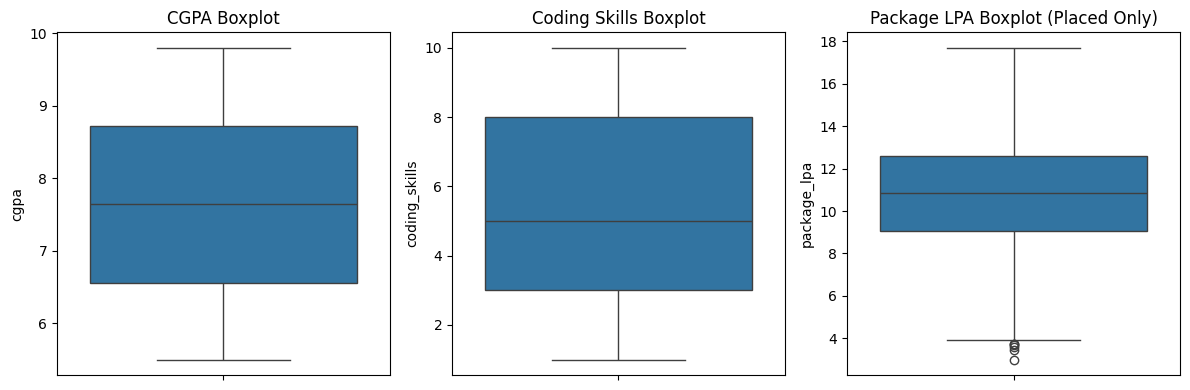

In [8]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
sns.boxplot(y=df['cgpa'])
plt.title('CGPA Boxplot')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['coding_skills'])
plt.title('Coding Skills Boxplot')

plt.subplot(1, 3, 3)
sns.boxplot(y=df[df['package_lpa'] > 0]['package_lpa'])
plt.title('Package LPA Boxplot (Placed Only)')

plt.tight_layout()
plt.show()

## 9. Create Derived Features
Let's create composite metrics to highlight analytical insights:
- **Total Skill Score**: Sum of coding skills and communication skills.
- **Academic Performance Index (API)**: Weighted score combining CGPA and penalizing backlogs.
- **Employability Score**: Combined score calculated from skills, CGPA, and internship completion.

In [9]:
df['total_skill_score'] = df['coding_skills'] + df['communication_skills']
df['academic_performance_index'] = (df['cgpa'] * 10) - (df['backlogs'] * 5)
df['employability_score'] = (df['total_skill_score'] * 0.4) + (df['cgpa'] * 0.4) + (df['internships'] * 2.0)

df[['total_skill_score', 'academic_performance_index', 'employability_score']].head()

,total_skill_score,academic_performance_index,employability_score
0,8,74.0,10.560
1,7,76.0,6.240
2,8,51.2,5.848
3,13,80.1,8.404
4,10,81.2,9.648


## 10. Save the Cleaned Dataset

In [10]:
cleaned_path = '../data/cleaned/placement_data_cleaned.csv'
df.to_csv(cleaned_path, index=False)
print(f"Successfully saved cleaned dataset to: {cleaned_path}")

Successfully saved cleaned dataset to: ../data/cleaned/placement_data_cleaned.csv
